# ANN (Iris Dataset + Graphs)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

In [14]:
data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
model_ann = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

model_ann.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [18]:
history_ann = model_ann.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.1250 - loss: 1.0981 - val_accuracy: 0.3000 - val_loss: 1.0952
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1833 - loss: 1.0880 - val_accuracy: 0.3333 - val_loss: 1.0915
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2250 - loss: 1.0787 - val_accuracy: 0.4000 - val_loss: 1.0887
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2583 - loss: 1.0699 - val_accuracy: 0.4000 - val_loss: 1.0860
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2750 - loss: 1.0615 - val_accuracy: 0.4000 - val_loss: 1.0834
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2917 - loss: 1.0527 - val_accuracy: 0.4333 - val_loss: 1.0809
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2917 - loss: 1.0439 - val_accuracy: 0.4667 - val_loss: 1.0784
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3000 - loss: 1.0345 - val_accuracy: 0.4667 - val_loss: 1.0757

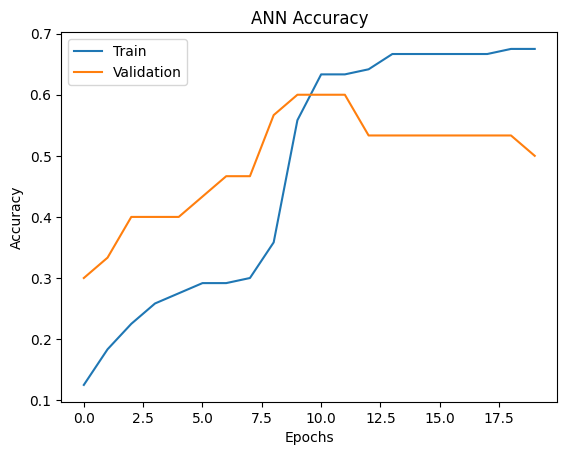

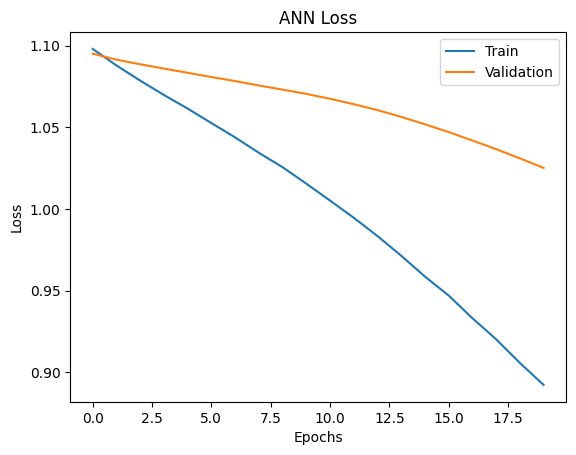

In [19]:
# Accuracy graph
plt.figure()
plt.plot(history_ann.history['accuracy'])
plt.plot(history_ann.history['val_accuracy'])
plt.title("ANN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss graph
plt.figure()
plt.plot(history_ann.history['loss'])
plt.plot(history_ann.history['val_loss'])
plt.title("ANN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


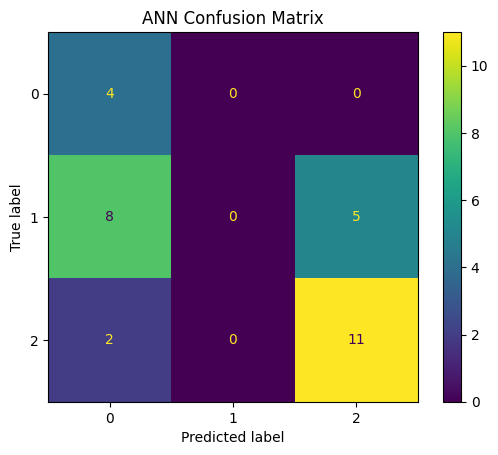

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model_ann.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("ANN Confusion Matrix")
plt.show()

# CNN (MNIST + Visualization)

In [21]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


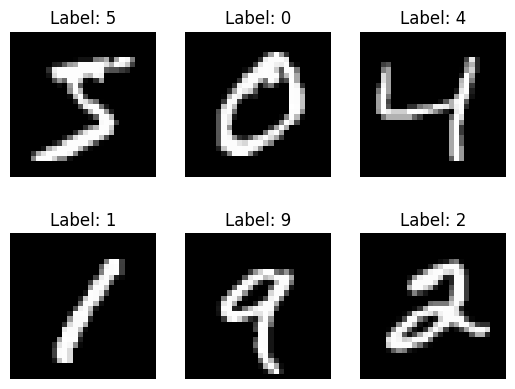

In [22]:
plt.figure()
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [23]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [27]:
model_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)), # Explicitly define Input layer
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [28]:
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 30ms/step - accuracy: 0.9575 - loss: 0.1413 - val_accuracy: 0.9803 - val_loss: 0.0605
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 29ms/step - accuracy: 0.9848 - loss: 0.0487 - val_accuracy: 0.9865 - val_loss: 0.0439
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9890 - loss: 0.0336 - val_accuracy: 0.9913 - val_loss: 0.0267
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 30ms/step - accuracy: 0.9921 - loss: 0.0245 - val_accuracy: 0.9887 - val_loss: 0.0357
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9946 - loss: 0.0182 - val_accuracy: 0.9916 - val_loss: 0.0278


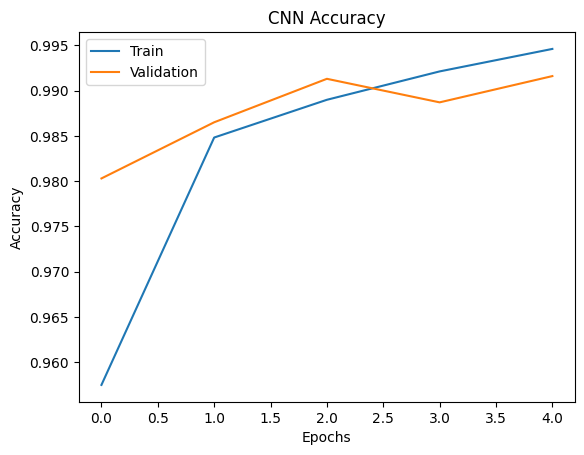

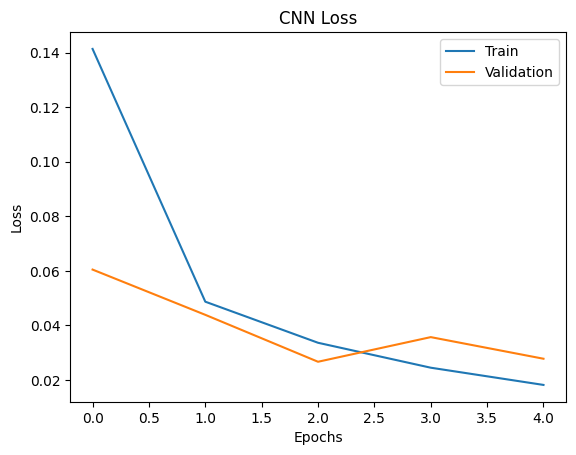

In [30]:
# Accuracy
plt.figure()
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.figure()
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title("CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


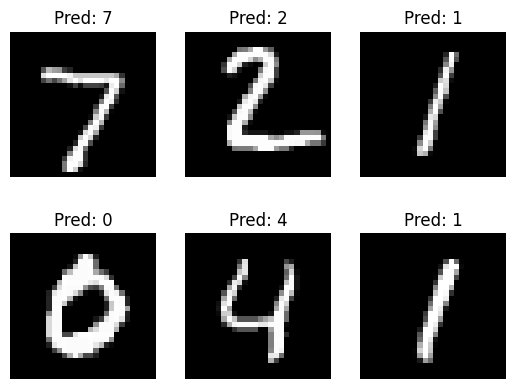

In [31]:
predictions = model_cnn.predict(X_test)

plt.figure()
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {np.argmax(predictions[i])}")
    plt.axis('off')
plt.show()